# Realistic Sources for GWs/FRBs Associations

We generate the redshift distribution of sources coming from NSBH mergers, that we consider as associated sources of FRB events. The rates here follow distributions of NS-NS or NS-BH models, following star formation and time delay models.

Based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] and [[2011.02717](https://arxiv.org/abs/2011.02717)].

In [1]:
import sys
sys.path.append('../../Python_scripts')

__Importing modules and constants__

In [2]:
from config import *

__Importing useful support functions__

In [3]:
from support import *

__Importing cosmological functions__

In [4]:
from cosmo_support import *

**Plotting Options**

In [5]:
## Plotting
plt.rcParams['font.family'] ='Times New Roman'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [6]:
SAVE_FIG = False

-------------------------------------

## Redshift distribution of events

Following [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] and references therein, we assume a redshift distribution of our GWs events:

$$
P(z) \sim \frac{4 \pi D_c^2(z) R(z)}{H(z)(1+z)},
$$

where $D_c(z)$ is the comoving distance to the source and $R(z)$ denotes the rate of events per redshift, and is given by:

$$
 R(z)  =
  \begin{cases}
            1+2z : z \leq 1 \\
            \frac{3}{4}(5-z) : 1<z<5\\
            0 : z \geq 5
  \end{cases}
$$

In [7]:
redshift_array = np.linspace(0.05, 2, 500)

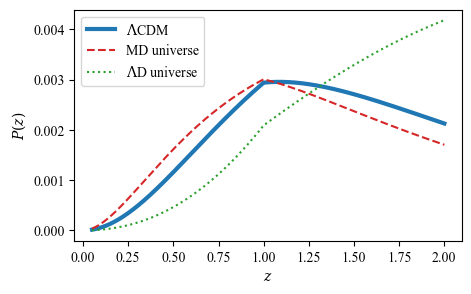

In [8]:
fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot(111)

ax1.plot(redshift_array, redshift_distribution(redshift_array, HUBBLE, OMEGA_MATTER, w=W_LAMBDA), label=r'$\Lambda$CDM', c='tab:blue', lw=3)
ax1.plot(redshift_array, redshift_distribution(redshift_array, HUBBLE, 1, w=W_LAMBDA), label='MD universe', c='tab:red', ls='--')
ax1.plot(redshift_array, redshift_distribution(redshift_array, HUBBLE, 0, w=W_LAMBDA), label=r'$\Lambda$D universe', c='tab:green', ls=':')

ax1.set_ylabel(r'$P(z)$')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left', fontsize=10)

if SAVE_FIG:
    plt.savefig("figures/merger_rate_cosmology.png", dpi=200, bbox_inches='tight')

plt.show()
plt.close()

Draw redshifts that follow the distribution

In [9]:
Pz_array = rng.choice(redshift_array, size=5000, replace=True,\
                            p=redshift_distribution(redshift_array, HUBBLE, OMEGA_MATTER, w=W_LAMBDA))
Uniform_z_array = rng.choice(redshift_array, size=5000, replace=True)

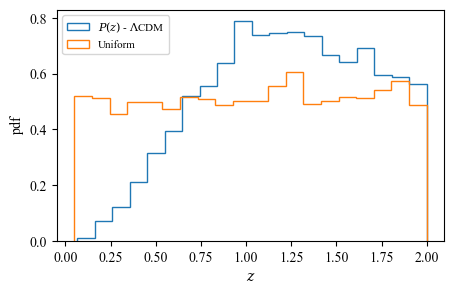

In [10]:
fig = plt.figure(figsize=(5, 3))
ax1 = fig.add_subplot(111)

NBins = 20

ax1.hist(Pz_array, bins=NBins, density=True, histtype='step', label=r'$P(z)$ - $\Lambda$CDM')
ax1.hist(Uniform_z_array, bins=NBins, density=True, histtype='step', label='Uniform')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel('pdf')
ax1.legend(loc='upper left', fontsize=8)

plt.show()

Additional distributions from Jin-Ping Zhu's paper [[2011.02717](https://arxiv.org/abs/2011.02717)].

- The **Gaussian** delay model
- The **LogNormal** delay model
- The **PowerLaw** delay model

In [11]:
Pz_gaussian = rng.choice(redshift_array, size=5000, replace=True,\
                            p=redshift_distribution(redshift_array, method='gaussian'))
Pz_LogNormal = rng.choice(redshift_array, size=5000, replace=True,\
                            p=redshift_distribution(redshift_array, method='lognormal'))
Pz_power = rng.choice(redshift_array, size=5000, replace=True,\
                            p=redshift_distribution(redshift_array, method='powerlaw'))

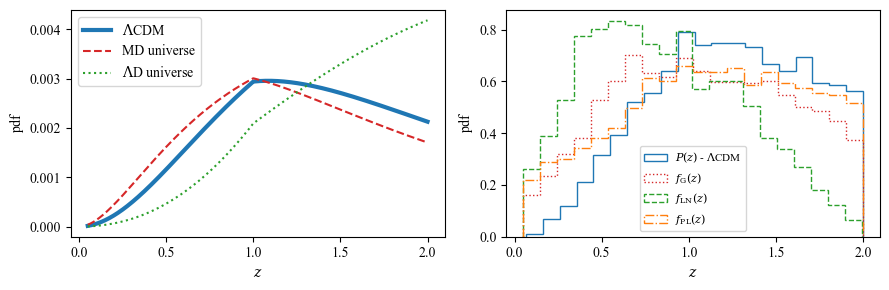

In [12]:
fig = plt.figure(figsize=(9, 3))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

NBins = 20

ax1.plot(redshift_array, redshift_distribution(redshift_array, HUBBLE, OMEGA_MATTER, w=W_LAMBDA), label=r'$\Lambda$CDM', c='tab:blue', lw=3)
ax1.plot(redshift_array, redshift_distribution(redshift_array, HUBBLE, 1, w=W_LAMBDA), label='MD universe', c='tab:red', ls='--')
ax1.plot(redshift_array, redshift_distribution(redshift_array, HUBBLE, 0, w=W_LAMBDA), label=r'$\Lambda$D universe', c='tab:green', ls=':')

ax1.set_ylabel(r'pdf')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left', fontsize=10)

ax2.hist(Pz_array, bins=NBins, density=True, histtype='step', label=r'$P(z)$ - $\Lambda$CDM', color='tab:blue', linestyle='-', lw=5)
ax2.hist(Pz_gaussian, bins=NBins, density=True, histtype='step', label=r'$f_{\rm G}(z)$', color='tab:red', linestyle=':', lw=2)
ax2.hist(Pz_LogNormal, bins=NBins, density=True, histtype='step', label=r'$f_{\rm LN}(z)$', color='tab:green', linestyle='--', lw=2)
ax2.hist(Pz_power, bins=NBins, density=True, histtype='step', label=r'$f_{\rm PL}(z)$', color='tab:orange', linestyle='-.', lw=2)


ax2.set_xlabel(r'$z$')
ax2.set_ylabel(r'pdf')
ax2.legend(fontsize=8)

plt.tight_layout()

if SAVE_FIG:
    plt.savefig("figures/merger_rate_summary_plot.png", dpi=200, bbox_inches='tight')

plt.show()
plt.close()

## Luminosity distance and dispersion measure

1. **Errors**

In [13]:
sim_error_interpolations = np.load(f'./quantile_linear_interpolations.npz')

LVK_error = sim_error_interpolations['LVK_interpolation']
CE_error = sim_error_interpolations['CE_interpolation']

In [14]:
def GWs_error(z, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, method='constant'):
    if method=='LVK':
        sigma_ratio = func_lin(z, *LVK_error)/100
        dL=luminosity_distance(z, H0, Om, w)
        return sigma_ratio*dL
    elif method=='CE':
        sigma_ratio = func_lin(z, *CE_error)/100
        dL=luminosity_distance(z, H0, Om, w)
        return sigma_ratio*dL
    elif method=='Wei':
        return sigma_dL(z, H0, Om, w, method=method)
    elif method=='constant':
        return sigma_dL(z, H0, Om, w, method=method)
    else:
        print("Wrong error generation method! Choose from: 'LVK', 'CE', 'Wei', and 'constant'.")

2. **Drawing random GWs events**

In [15]:
## Number of random events
N_EVENTS = 50

## Draw random redshifts, based on given redshift
z_centre = draw_redshift_distribution(redshift_array, H0=HUBBLE, Omega_m=OMEGA_MATTER, 
                                          N_draws=N_EVENTS, method='rates')


## Theoretical dL, fiducial cosmo
dL_centre = luminosity_distance(z=z_centre, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA)
## Theoretical DM, fiducial cosmo
# DM_centre = dispersion_measure(z=z_centre, H0=HUBBLE, Om=OMEGA_MATTER)

In [16]:
## Calculate errors
sigma_dL = GWs_error(z_centre, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, method='constant')

## Scatter observations according to errors
dL_obs_centre = rng.normal(dL_centre, sigma_dL)

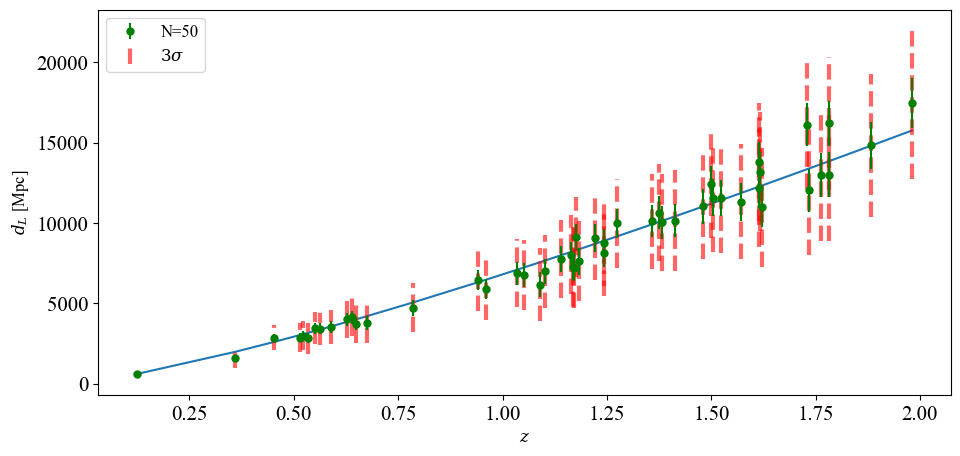

In [17]:
fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(111)

ax1.plot(np.sort(z_centre), np.sort(dL_centre), c='tab:blue')


ax1.errorbar(z_centre, dL_obs_centre, yerr=sigma_dL, marker='o', ls='', ms=5, c='g', label=f'N={N_EVENTS}', zorder=10)

erplot2 = ax1.errorbar(z_centre, dL_obs_centre, yerr=3*sigma_dL, marker='', ls='',\
                       ms=5, ecolor='r', alpha=0.6, elinewidth=3, label=r'$3 \sigma$')
erplot2[-1][0].set_linestyle('--')

ax1.set_ylabel(r'$d_{L}$ [Mpc]', fontsize=12)
ax1.set_xlabel(r'$z$', fontsize=12)
ax1.legend(loc='upper left', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=15)

plt.show()

In [18]:
print(f"Events with negative pdf tails: {np.sum((dL_obs_centre-3.5*sigma_dL)<0)} out of {N_EVENTS} events.")

Events with negative pdf tails: 0 out of 50 events.


3. **Drawing random FRB events**

In [19]:
DATA_PATH = '../FRB_cosmo/interpolation/095_C0mean.npz'
Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = FRBs_load_and_create_interpolators(DATA_PATH)

In [20]:
# Theoretical DM, fiducial cosmo
DM_centre = dispersion_measure(z_centre, H0=HUBBLE, Om=OMEGA_MATTER, w=W_LAMBDA, alpha=f_ALPHA, f_IGM_0 = f_IGM)

In [ ]:
## Simple Gaussian pdf - Scatter observations according to errors
DM_obs_centre_gauss = rng.normal(DM_centre, SIGMA_DM)

## Modelling the DM pdf -- Standard HOF
DM_obs_centre = np.zeros_like(z_centre)
s_DM_obs = np.zeros_like(z_centre)

## Modelling the DM pdf -- Standard cosmology
DM_obs_centre_fid_cosmo = np.zeros_like(z_centre)
s_DM_obs_fid_cosmo = np.zeros_like(z_centre)

## Modelling the DM pdf -- External DM (i.e. including DM_host)
DM_obs_centre_ext = np.zeros_like(z_centre)
s_DM_obs_ext = np.zeros_like(z_centre)

for idx, z_val in enumerate(tqdm(z_centre)):
    DM_obs_centre[idx], s_DM_obs[idx] = \
        DM_diff_sampling(z=z_val, 
                        S=S_FRB, HOF=HOF,
                        sigma_error_inter=sigma_error_inter,
                        C0_sigma_inter=C0_sigma_inter,
                        A_sigma_inter=A_sigma_inter,
                        H0=HUBBLE, f_diff=f_IGM, f_diff_alpha=f_ALPHA,
                        Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
                        mode=None, #'standard'
                        Error_factor = 1
                        )

    DM_obs_centre_fid_cosmo[idx], s_DM_obs_fid_cosmo[idx] = \
        DM_diff_sampling(z=z_val, 
                        S=S_FRB, HOF=HOF,
                        sigma_error_inter=sigma_error_inter,
                        C0_sigma_inter=C0_sigma_inter,
                        A_sigma_inter=A_sigma_inter,
                        H0=HUBBLE, f_diff=f_IGM, f_diff_alpha=f_ALPHA,
                        Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
                        mode='standard',
                        Error_factor = 1
                        )

    DM_obs_centre_ext[idx], s_DM_obs_ext[idx] = \
        DM_ext_sampling(z=z_val, 
                        S=S_FRB, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
                        sigma_error_inter=sigma_error_inter,
                        C0_sigma_inter=C0_sigma_inter,
                        A_sigma_inter=A_sigma_inter,
                        Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
                        Error_factor = 1
                        )    

 20%|████████████████▍                                                                 | 10/50 [00:46<03:05,  4.64s/it]

In [22]:
# for idx, z_val in enumerate(tqdm(z_centre)):
#     DM_obs_centre_ext[idx], s_DM_obs_ext[idx] = \
#         DM_ext_sampling(z=z_val, 
#                         S=S_FRB, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
#                         sigma_error_inter=sigma_error_inter,
#                         C0_sigma_inter=C0_sigma_inter,
#                         A_sigma_inter=A_sigma_inter,
#                         Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
#                         Error_factor = 1
#                         )    

  8%|██████▋                                                                            | 4/50 [00:18<03:32,  4.63s/it]


KeyboardInterrupt: 

In [ ]:
fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(111)

ax1.plot(np.sort(z_centre), np.sort(DM_centre), c='tab:blue')
# erplot2 = ax1.errorbar(z_centre, dL_obs_centre, yerr=3*sigma_dL, marker='', ls='',\
#                        ms=5, ecolor='r', alpha=0.6, elinewidth=3, label=r'$3 \sigma$')
# erplot2[-1][0].set_linestyle('--')

ax1.errorbar(z_centre, DM_obs_centre, yerr=s_DM_obs, marker='o', ls='', ms=5, c='g', label=f'N={N_EVENTS}')
ax1.errorbar(z_centre, DM_obs_centre_gauss, yerr=SIGMA_DM, marker='x', ls='', ms=5, c='tab:red', label=f'Gaussian', alpha=0.7)
ax1.errorbar(z_centre, DM_obs_centre_fid_cosmo, yerr=s_DM_obs_fid_cosmo, marker='+',\
             ls='', ms=5, c='tab:grey', label='Fiducial Cosmo', alpha=0.9)


ax1.set_ylabel(r'${\rm DM}_{\rm diff}$ [pc/cm$^3$]', fontsize=12)
ax1.set_xlabel(r'$z$', fontsize=12)
ax1.legend(loc='upper left', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=15)

plt.show()

In [ ]:
fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(111)

ax1.plot(np.sort(z_centre), np.sort(DM_centre), c='tab:blue')
ax1.errorbar(z_centre, DM_obs_centre, yerr=s_DM_obs, marker='o', ls='', ms=5, c='g', label=r'${\rm DM}_{\rm diff}$ [pc/cm$^3$]')
ax1.errorbar(z_centre[:-40], DM_obs_centre_ext[:-40], yerr=s_DM_obs_ext[:-40], marker='x',\
             ls='', ms=5, c='tab:red', label=r'${\rm DM}_{\rm ext}$ [pc/cm$^3$]', alpha=0.7)

ax1.set_ylabel(r'${\rm DM}$ [pc/cm$^3$]', fontsize=12)
ax1.set_xlabel(r'$z$', fontsize=12)
ax1.legend(loc='upper left', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=15)

plt.show()

In [ ]:
DM_diff_sampling(z=0.5, 
                S=S_FRB, HOF=HOF,
                sigma_error_inter=sigma_error_inter,
                C0_sigma_inter=C0_sigma_inter,
                A_sigma_inter=A_sigma_inter,
                H0=HUBBLE, f_diff=f_IGM, f_diff_alpha=f_ALPHA,
                Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
                mode=None, #'standard'
                Error_factor = 1
                )

In [ ]:
DM_ext_sampling(z=0.5, 
                S=S_FRB, HOF=HOF, SIGMA_HOST=SIGMA_HOST, EXP_MU=EXP_MU,
                sigma_error_inter=sigma_error_inter,
                C0_sigma_inter=C0_sigma_inter,
                A_sigma_inter=A_sigma_inter,
                Om=OMEGA_MATTER, w=W_LAMBDA, N_draws=1,
                Error_factor = 1
                )  

---------------------------------------------------------

**Visualisations (Sources)**

In [ ]:
fig = plt.figure(figsize=(14, 4))
ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3)

ax1.plot(np.sort(z_centre), np.sort(dL_centre), c='tab:blue')
ax1.errorbar(z_centre, dL_obs_centre, yerr=sigma_dL, marker='o', ls='', ms=5, c='tab:red', label=f'N={N_EVENTS}', zorder=10)
ax1.set_ylabel(r'$d_{L}$ [Mpc]', fontsize=12)
ax1.set_xlabel(r'$z$', fontsize=12)
ax1.legend(loc='upper left', fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=15)

ax2.plot(np.sort(z_centre), np.sort(DM_centre), c='tab:blue')
ax2.errorbar(z_centre, DM_obs_centre, yerr=s_DM_obs, marker='o', ls='', ms=5, c='tab:red', label=f'N={N_EVENTS}')
ax2.set_ylabel(r'${\rm DM}_{\rm diff}$ [pc/cm$^3$]', fontsize=12)
ax2.set_xlabel(r'$z$', fontsize=12)
ax2.legend(loc='upper left', fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=15)

ax3.plot(np.sort(z_centre), np.sort(DM_centre), c='tab:blue')
ax3.errorbar(z_centre, DM_obs_centre_ext, yerr=s_DM_obs_ext, marker='o', ls='', ms=5, c='tab:red', label=f'N={N_EVENTS}')
ax3.set_ylabel(r'${\rm DM}_{\rm ext}$ [pc/cm$^3$]', fontsize=12)
ax3.set_xlabel(r'$z$', fontsize=12)
ax3.legend(loc='upper left', fontsize=12)
ax3.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()